# 1. Análisis Exploratorio de Datos (EDA) — RetailMax

**Objetivo.** Comprender la estructura, calidad y relaciones del conjunto de datos antes de segmentar clientes. El análisis es reproducible: las estadísticas se calculan directamente desde `data/retailmax.csv`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titleweight'] = 'bold'

DATA_PATH = Path('data/retailmax.csv')
df = pd.read_csv(DATA_PATH, dtype={'CustomerID': str})
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0001,Male,19,15,39
1,0002,Male,21,15,81
2,0003,Female,20,16,6
3,0004,Female,23,16,77
4,0005,Female,31,17,40


## Revisión inicial y calidad de datos

Primero verificamos dimensiones, tipos, duplicados, valores faltantes y rangos. `CustomerID` es un identificador, no una medida del cliente; por ello no se utilizará como variable de segmentación.

In [2]:
print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
display(df.info())
display(df.describe(include='all').T)

quality = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'faltantes': df.isna().sum(),
    'únicos': df.nunique()
})
display(quality)
print(f'Filas duplicadas: {df.duplicated().sum()}')
print(f'CustomerID duplicados: {df["CustomerID"].duplicated().sum()}')

Dimensiones: 200 filas × 5 columnas
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    str  
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3), str(2)
memory usage: 7.9 KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,200,200,0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,200,2,Female,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,200.0,NaN,NaN,NaN,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Annual Income (k$),200.0,NaN,NaN,NaN,60.56,26.264721,15.0,41.5,61.5,78.0,137.0
Spending Score (1-100),200.0,NaN,NaN,NaN,50.2,25.823522,1.0,34.75,50.0,73.0,99.0


,tipo,faltantes,únicos
CustomerID,str,0,200
Gender,str,0,2
Age,int64,0,51
Annual Income (k$),int64,0,64
Spending Score (1-100),int64,0,84


Filas duplicadas: 0
CustomerID duplicados: 0


**Hallazgo de calidad.** Hay 200 registros, no existen valores faltantes ni filas/identificadores duplicados. Las edades (18–70), ingresos (15–137 k$) y puntuaciones (1–99) están dentro de rangos plausibles. El conjunto está listo para el análisis sin imputación ni eliminación de observaciones.

## 1. ¿Cuál es la distribución de edades de los clientes?

,Edad
count,200.00
mean,38.85
median,36.00
std,13.97
min,18.00
max,70.00


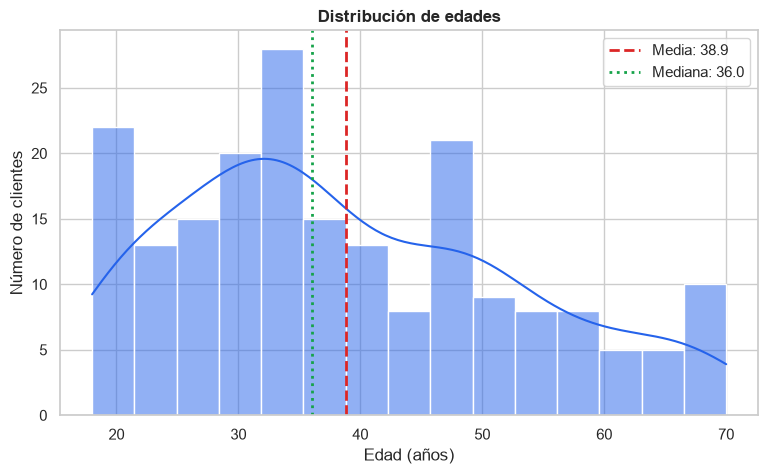

In [3]:
age_stats = df['Age'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)
display(age_stats.to_frame('Edad'))

fig, ax = plt.subplots()
sns.histplot(df['Age'], bins=15, kde=True, color='#2563EB', edgecolor='white', ax=ax)
ax.axvline(df['Age'].mean(), color='#DC2626', ls='--', lw=2,
           label=f'Media: {df["Age"].mean():.1f}')
ax.axvline(df['Age'].median(), color='#16A34A', ls=':', lw=2,
           label=f'Mediana: {df["Age"].median():.1f}')
ax.set(title='Distribución de edades', xlabel='Edad (años)', ylabel='Número de clientes')
ax.legend()
plt.show()

**Interpretación.** La edad media es **38.85 años** y la mediana **36 años**; el 50% central se encuentra entre **28.75 y 49 años**. El rango completo es de 18 a 70 años y la cola hacia edades mayores explica que la media sea superior a la mediana. RetailMax atiende una base amplia, con mayor presencia relativa de adultos jóvenes.

## 2. ¿Existen diferencias en los ingresos anuales entre hombres y mujeres?

,count,mean,median,std,min,max
Gender,,,,,,
Female,112,59.25,60.0,26.01,16,126
Male,88,62.23,62.5,26.64,15,137


Mann–Whitney U = 4596; p = 0.414


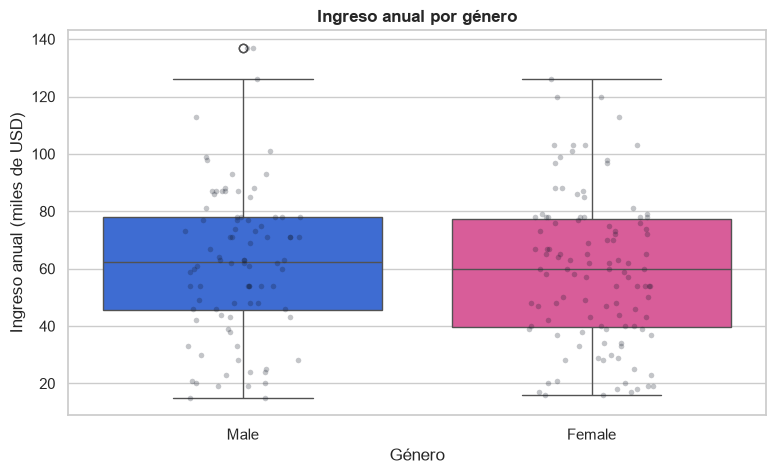

In [4]:
income_by_gender = (df.groupby('Gender')['Annual Income (k$)']
                    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
                    .round(2))
display(income_by_gender)

female_income = df.loc[df['Gender'].eq('Female'), 'Annual Income (k$)']
male_income = df.loc[df['Gender'].eq('Male'), 'Annual Income (k$)']
u_stat, p_value = mannwhitneyu(female_income, male_income, alternative='two-sided')
print(f'Mann–Whitney U = {u_stat:.0f}; p = {p_value:.3f}')

fig, ax = plt.subplots()
sns.boxplot(data=df, x='Gender', y='Annual Income (k$)', hue='Gender',
            palette={'Male': '#2563EB', 'Female': '#EC4899'}, legend=False, ax=ax)
sns.stripplot(data=df, x='Gender', y='Annual Income (k$)', color='#111827',
              alpha=.25, jitter=.18, size=4, ax=ax)
ax.set(title='Ingreso anual por género', xlabel='Género', ylabel='Ingreso anual (miles de USD)')
plt.show()

**Interpretación.** Los hombres presentan una media de **62.23 k$** y las mujeres de **59.25 k$** (diferencia descriptiva de 2.98 k$); las medianas son 62.5 y 60 k$, respectivamente. Sin embargo, las distribuciones se superponen ampliamente y la prueba no paramétrica de Mann–Whitney no detecta evidencia de diferencia al nivel de 5% (**p = 0.414**). No conviene diseñar campañas suponiendo distinto poder adquisitivo únicamente por género.

## 3. ¿Cómo se distribuye la puntuación de gasto entre los diferentes rangos de edades?

,count,mean,median,std,min,max
Age Range,,,,,,
18–29,55,58.58,56.0,23.77,5,97
30–39,61,61.10,72.0,28.30,1,99
40–49,39,34.95,36.0,18.53,5,95
50–59,25,34.72,43.0,18.94,4,60
60–70,20,43.00,48.5,16.67,3,59


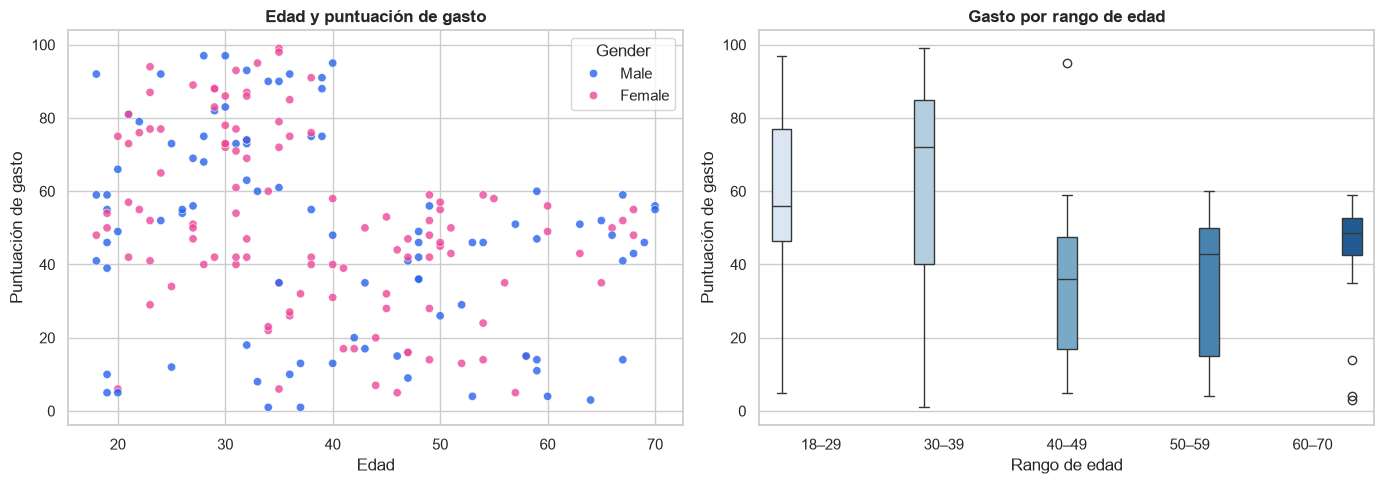

In [5]:
labels = ['18–29', '30–39', '40–49', '50–59', '60–70']
df['Age Range'] = pd.cut(df['Age'], bins=[17, 29, 39, 49, 59, 70], labels=labels)
spending_by_age = (df.groupby('Age Range', observed=True)['Spending Score (1-100)']
                   .agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2))
display(spending_by_age)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)', hue='Gender',
                palette={'Male': '#2563EB', 'Female': '#EC4899'}, alpha=.8, ax=axes[0])
axes[0].set(title='Edad y puntuación de gasto', xlabel='Edad', ylabel='Puntuación de gasto')
sns.boxplot(data=df, x='Age Range', y='Spending Score (1-100)', hue='Age Range',
            palette='Blues', legend=False, ax=axes[1])
axes[1].set(title='Gasto por rango de edad', xlabel='Rango de edad', ylabel='Puntuación de gasto')
plt.tight_layout()
plt.show()

**Interpretación.** Los grupos de 18–29 y 30–39 años tienen los promedios de gasto más altos (**58.58** y **61.10**) y también una gran dispersión. A partir de los 40 años el promedio disminuye: 34.95 (40–49), 34.72 (50–59) y 43.00 (60–70). Existe una excepción de alto gasto en 40–49, por lo que la edad orienta la segmentación pero no determina por sí sola el comportamiento individual.

## 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?

Correlación de Pearson: 0.010


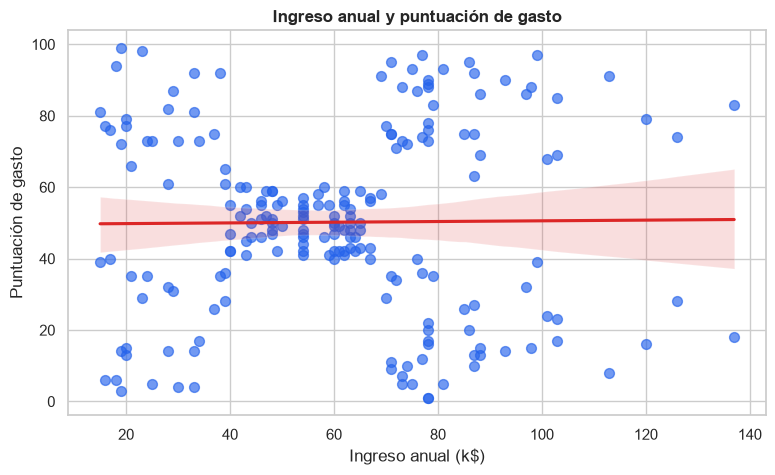

In [6]:
income_spending_corr = df['Annual Income (k$)'].corr(df['Spending Score (1-100)'])
print(f'Correlación de Pearson: {income_spending_corr:.3f}')

fig, ax = plt.subplots()
sns.regplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
            scatter_kws={'alpha': .65, 's': 50, 'color': '#2563EB'},
            line_kws={'color': '#DC2626'}, ax=ax)
ax.set(title='Ingreso anual y puntuación de gasto', xlabel='Ingreso anual (k$)',
       ylabel='Puntuación de gasto')
plt.show()

**Interpretación.** La correlación de Pearson es **0.010**, prácticamente nula. Esto significa que no existe una relación *lineal* global entre ingreso y gasto. La dispersión sí muestra subgrupos —sobre todo entre ingresos altos—, por lo que correlación nula no equivale a ausencia total de estructura.

## 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?

,count,mean,median,std,min,max
Income Range,,,,,,
Bajo (<40 k$),46,49.74,50.5,31.48,3,99
Medio (40–69 k$),78,50.41,50.0,7.56,40,91
Alto (≥70 k$),76,50.26,51.5,33.41,1,97


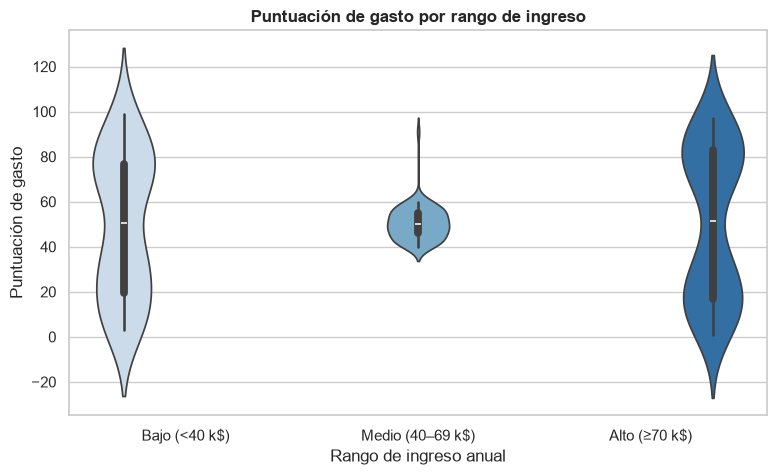

In [7]:
income_labels = ['Bajo (<40 k$)', 'Medio (40–69 k$)', 'Alto (≥70 k$)']
df['Income Range'] = pd.cut(df['Annual Income (k$)'], bins=[0, 39, 69, np.inf],
                            labels=income_labels)
spending_by_income = (df.groupby('Income Range', observed=True)['Spending Score (1-100)']
                      .agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2))
display(spending_by_income)

fig, ax = plt.subplots()
sns.violinplot(data=df, x='Income Range', y='Spending Score (1-100)',
               hue='Income Range', palette='Blues', inner='box', legend=False, ax=ax)
ax.set(title='Puntuación de gasto por rango de ingreso', xlabel='Rango de ingreso anual',
       ylabel='Puntuación de gasto')
plt.show()

**Interpretación.** Las medias son muy similares: 49.74, 50.41 y 50.26 para ingreso bajo, medio y alto. La diferencia importante está en la **dispersión**: los grupos bajo y alto contienen clientes con gasto tanto muy bajo como muy alto, mientras el rango medio se concentra cerca de 50. Esta heterogeneidad respalda el uso de clustering.

## 6. ¿Cuál es la proporción de clientes por género?

,Clientes,Porcentaje
Gender,,
Female,112,56.0
Male,88,44.0


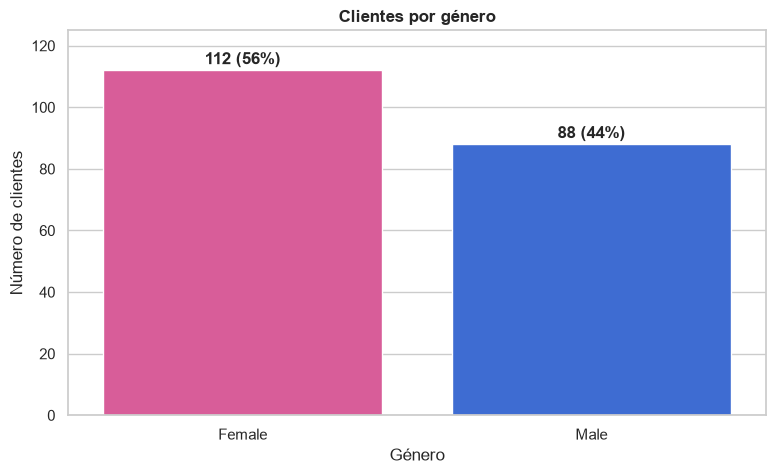

In [8]:
gender_counts = df['Gender'].value_counts()
gender_share = (df['Gender'].value_counts(normalize=True).mul(100).round(1))
display(pd.DataFrame({'Clientes': gender_counts, 'Porcentaje': gender_share}))

fig, ax = plt.subplots()
sns.barplot(x=gender_counts.index, y=gender_counts.values, hue=gender_counts.index,
            palette={'Male': '#2563EB', 'Female': '#EC4899'}, legend=False, ax=ax)
for patch, n in zip(ax.patches, gender_counts.values):
    ax.text(patch.get_x() + patch.get_width()/2, n + 2, f'{n} ({n/len(df):.0%})',
            ha='center', fontweight='bold')
ax.set(title='Clientes por género', xlabel='Género', ylabel='Número de clientes', ylim=(0, 125))
plt.show()

**Interpretación.** Hay **112 mujeres (56%)** y **88 hombres (44%)**. La muestra presenta una mayoría femenina moderada, pero ambos grupos tienen representación suficiente para comparaciones descriptivas.

## 7. ¿Qué grupos de edad gastan más en promedio?

,Gasto promedio
Age Range,
30–39,61.10
18–29,58.58
60–70,43.00
40–49,34.95
50–59,34.72


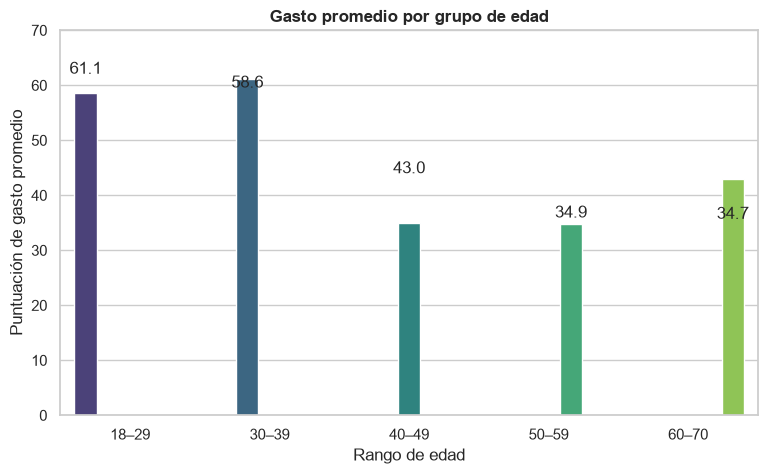

In [9]:
mean_spending_age = (df.groupby('Age Range', observed=True)['Spending Score (1-100)']
                     .mean().sort_values(ascending=False))
display(mean_spending_age.round(2).to_frame('Gasto promedio'))

fig, ax = plt.subplots()
sns.barplot(x=mean_spending_age.index, y=mean_spending_age.values,
            hue=mean_spending_age.index, palette='viridis', legend=False, ax=ax)
for patch, value in zip(ax.patches, mean_spending_age.values):
    ax.text(patch.get_x() + patch.get_width()/2, value + 1, f'{value:.1f}', ha='center')
ax.set(title='Gasto promedio por grupo de edad', xlabel='Rango de edad',
       ylabel='Puntuación de gasto promedio', ylim=(0, 70))
plt.show()

**Interpretación.** El grupo de **30–39 años** gasta más en promedio (**61.10**), seguido por 18–29 (**58.58**). El menor promedio corresponde a 50–59 (**34.72**). Estas cifras describen grupos y no implican que todos sus integrantes se comporten igual.

## 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?

Correlación de Pearson: -0.012


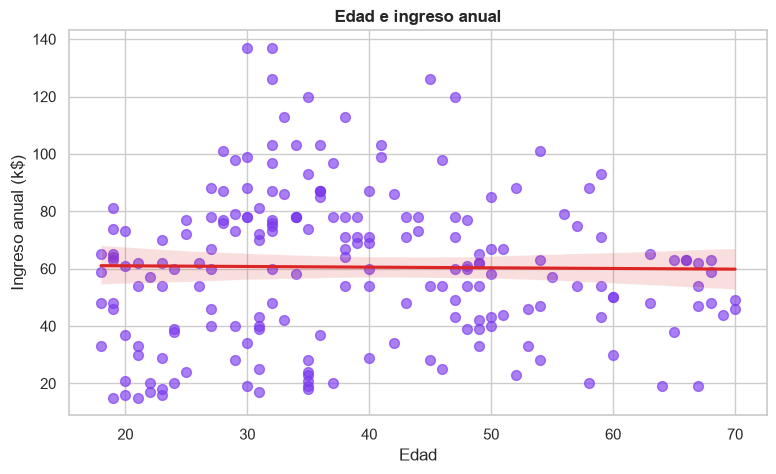

In [10]:
age_income_corr = df['Age'].corr(df['Annual Income (k$)'])
print(f'Correlación de Pearson: {age_income_corr:.3f}')

fig, ax = plt.subplots()
sns.regplot(data=df, x='Age', y='Annual Income (k$)',
            scatter_kws={'alpha': .65, 's': 50, 'color': '#7C3AED'},
            line_kws={'color': '#DC2626'}, ax=ax)
ax.set(title='Edad e ingreso anual', xlabel='Edad', ylabel='Ingreso anual (k$)')
plt.show()

**Interpretación.** La correlación es **−0.012**, esencialmente nula. En esta muestra la edad no permite anticipar el ingreso anual mediante una tendencia lineal.

## 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?

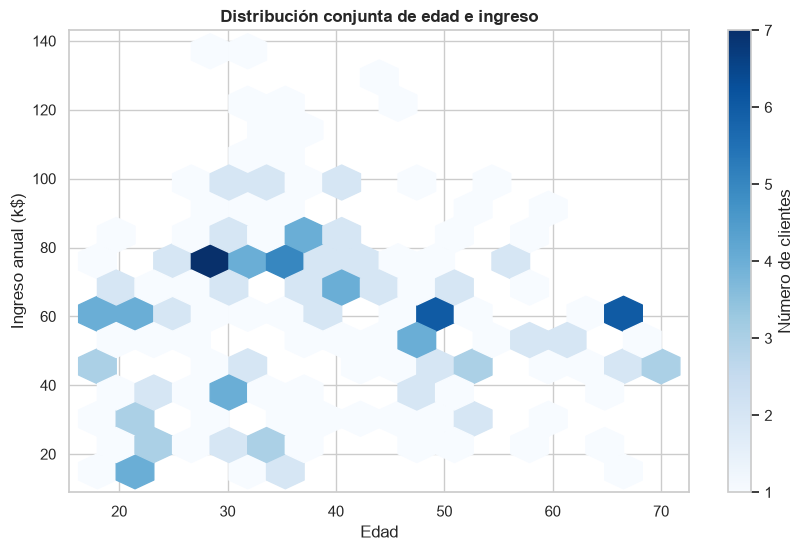

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
hb = ax.hexbin(df['Age'], df['Annual Income (k$)'], gridsize=15, cmap='Blues', mincnt=1)
fig.colorbar(hb, ax=ax, label='Número de clientes')
ax.set(title='Distribución conjunta de edad e ingreso', xlabel='Edad',
       ylabel='Ingreso anual (k$)')
plt.show()

**Interpretación.** La mayor densidad aparece alrededor de edades adultas jóvenes y medias con ingresos intermedios. También hay clientes de distintas edades en casi todos los niveles de ingreso, coherente con la correlación cercana a cero. El hexágono permite detectar concentración sin ocultar puntos superpuestos.

## 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?

,count,mean,median,std
Gender,,,,
Female,112,51.53,50.0,24.11
Male,88,48.51,50.0,27.90


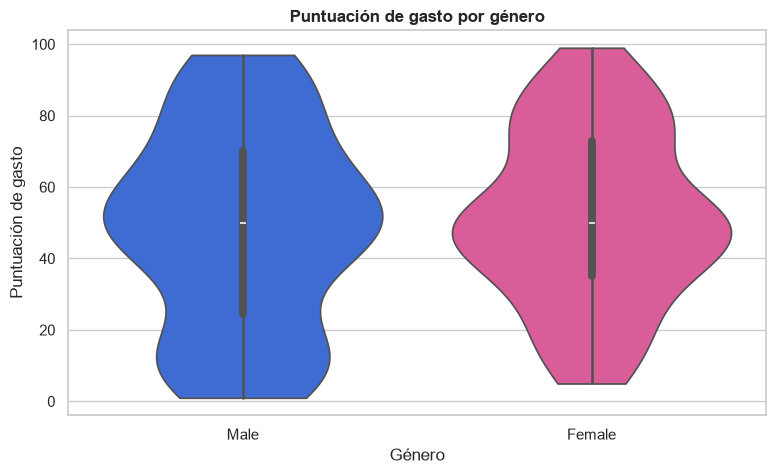

In [12]:
spending_gender = (df.groupby('Gender')['Spending Score (1-100)']
                   .agg(['count', 'mean', 'median', 'std']).round(2))
display(spending_gender)

fig, ax = plt.subplots()
sns.violinplot(data=df, x='Gender', y='Spending Score (1-100)', hue='Gender',
               palette={'Male': '#2563EB', 'Female': '#EC4899'}, inner='box',
               cut=0, legend=False, ax=ax)
ax.set(title='Puntuación de gasto por género', xlabel='Género',
       ylabel='Puntuación de gasto')
plt.show()

**Interpretación.** Las mujeres tienen una puntuación media de **51.53** y los hombres de **48.51**; ambos comparten mediana de **50** y sus distribuciones se superponen ampliamente. El género por sí solo aporta poca separación conductual.

## Síntesis visual y conclusiones del EDA

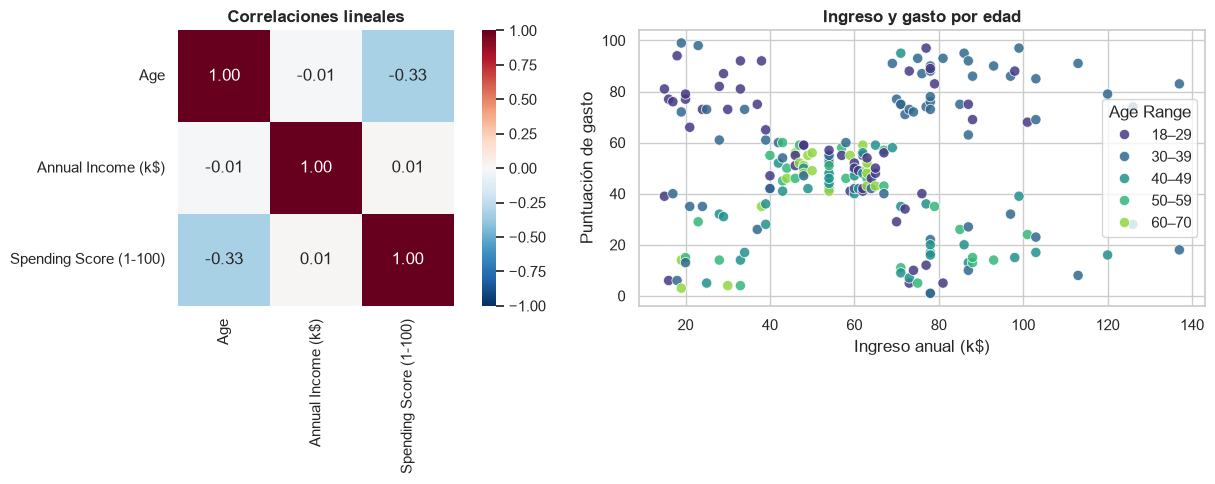

In [13]:
numeric = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df[numeric].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=axes[0])
axes[0].set_title('Correlaciones lineales')
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Age Range', palette='viridis', s=55, alpha=.85, ax=axes[1])
axes[1].set(title='Ingreso y gasto por edad', xlabel='Ingreso anual (k$)',
            ylabel='Puntuación de gasto')
plt.tight_layout()
plt.show()

### Conclusión del EDA

- La base está completa y limpia; no requiere imputación.
- Edad y gasto tienen una relación lineal negativa moderada, pero ingreso y gasto no siguen una sola relación lineal. En el plano ingreso–gasto aparecen zonas diferenciadas que justifican clustering.
- Para K-Means se usarán **edad, ingreso anual y puntuación de gasto**. Se excluirán `CustomerID` (identificador) y `Gender` (categórica y sin una separación clara de ingresos). Las tres variables numéricas deberán estandarizarse para que sus escalas no distorsionen las distancias.